# Messi, Ronaldo, Haaland & Mbappé: A Statistical Performance Comparison

**Author:** Ingavi Kilavuka

**Research Question:** Who is the GOAT in football or in other words, are there statistically significant differences in per-90 attacking performance between Lionel Messi, Cristiano Ronaldo, Erling Haaland, and Kylian Mbappé — and if so, who leads?

---

This is a **comparison problem**, not a prediction problem. The methodology is structured accordingly:
- Descriptive statistics and visualisations to characterise each player
- Hypothesis tests (Mann-Whitney U, Kruskal-Wallis, pairwise comparisons with Bonferroni correction) to determine whether differences are statistically significant
- A z-score standardised composite performance score with **equal, defensible weights** — no arbitrary multipliers

**Two analytical tiers** reflect genuine data availability constraints:
- **Tier 1 (Messi vs Ronaldo):** goals, assists, dribbles, key passes, all per 90 minutes. Both players have complete data.
- **Tier 2 (All four players):** goals and assists per 90 only. Dribbles and key passes are not reliably available for Haaland and Mbappé and are excluded rather than imputed.


## Table of Contents

1. [Business Understanding](#1-business-understanding)
2. [Data Preparation](#2-data-preparation)
3. [Descriptive Statistics](#3-descriptive-statistics)
4. [Exploratory Analysis](#4-exploratory-analysis)
   - [4.1 Boxplots & Violin Plots](#4.1-Boxplots-&-Violin-Plots)
   - [4.2 Bar Charts (Averages)](#4.2-Bar-Charts-(Averages))
   - [4.3 Season Trend Lines](#4.3-Season-Trend-Lines)
   - [4.4 Scatter Plot — Goals vs Assists](#4.4-Scatter-Plot-—-Goals-vs-Assistss)
   - [4.5 Radar Charts](#4.5-Radar-Charts)
5. [Statistical Tests](#5-statistical-tests)
   - [5.1 Normality Check](#5.1-Normality-Check)
   - [5.2 Tier 1: Messi vs Ronaldo (Mann-Whitney U)](#5.2-Tier-1:-Messi-vs-Ronaldo-(Mann-Whitney-U))
   - [5.3 Tier 2: All Four Players (Kruskal-Wallis + Pairwise)](#5.3-Tier-2:-All-Four-Players-(Kruskal-Wallis-+-Pairwise))
6. [Composite Performance Score](#6-composite-performance-score)
7. [Final Rankings & Conclusions](#7-final-rankings--conclusions)


# 1. Business Understanding

Comparisons of elite footballers are typically anecdotal or rely on headline counting stats (career goals, trophies) that don't account for playing time, era, or tactical role. This project builds a rigorous, per-90-minute statistical comparison of four elite forwards across their documented club careers, and tests whether observed differences are statistically meaningful — not just descriptively interesting.

**Key analytical decisions and their justifications:**

| Decision | Rationale |
|---|---|
| Per-90 metrics instead of totals | Adjusts for playing time — a player with 30 goals in 2000 minutes outperforms one with 30 goals in 3500 minutes |
| Mann-Whitney U instead of t-test | Shapiro-Wilk normality tests run first; sports performance data is typically right-skewed |
| Bonferroni correction on pairwise tests | Controls family-wise error rate when running multiple comparisons |
| Z-score composite score, not weighted sum | Eliminates arbitrary weights; each metric contributes equally on a common scale |
| Dribbles/key passes excluded from Tier 2 | These metrics are null for Haaland and Mbappé; comparison on incomplete data would be misleading |
| Season-wise z-score *not* used | Our dataset has 2–4 players per season — within-season standardisation on such a small group is statistically meaningless |


# 2. Data Preparation

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, shapiro
from itertools import combinations
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
PALETTE = {
    'Lionel Messi':    '#003DA5',   # Barcelona blue
    'Cristiano Ronaldo': '#D4000D', # Man Utd / Portugal red
    'Erling Haaland':  '#6CABDD',   # Man City sky blue
    'Kylian Mbappe':   '#EF3340',   # France / PSG red
}
%matplotlib inline

In [2]:
# Load raw data
raw = pd.read_csv(r"C:\Users\HomePC\Downloads\peer stats.csv")
print(f"Raw shape: {raw.shape}")
raw.head()

Raw shape: (181, 10)


,player,season,club,competition,goals,assists,appearances,minutes,dribbles_completed,key_passes
0,Lionel Messi,2004-05,FC Barcelona,All Competitions,1,0,9.0,234.0,6.0,NaN
1,Lionel Messi,2004-05,FC Barcelona,League,1,0,7.0,71.0,0.0,NaN
2,Lionel Messi,2004-05,FC Barcelona,Champions League,0,0,1.0,90.0,6.0,2.0
3,Cristiano Ronaldo,2004-05,Manchester United,All Competitions,9,8,50.0,3719.0,146.0,NaN
4,Cristiano Ronaldo,2004-05,Manchester United,League,5,4,33.0,2429.0,109.0,NaN


In [3]:
# ── Data cleaning ──────────────────────────────────────────────────────────────
# Keep All Competitions rows only — ensures we compare the same competition scope
df = raw[raw['competition'] == 'All Competitions'].copy()

# Drop rows missing the core shared metrics
df = df.dropna(subset=['goals', 'assists', 'appearances'])

# Convert numeric columns (some may have loaded as object)
for col in ['goals', 'assists', 'appearances', 'minutes', 'dribbles_completed', 'key_passes']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Cleaned shape: {df.shape}")
print(f"Players: {df['player'].unique()}")
print(f"Seasons per player:")
df.groupby('player')['season'].count()

Cleaned shape: (60, 10)
Players: ['Lionel Messi' 'Cristiano Ronaldo' 'Erling Haaland' 'Kylian Mbappe']
Seasons per player:


player
Cristiano Ronaldo    21
Erling Haaland        9
Kylian Mbappe         9
Lionel Messi         21
Name: season, dtype: int64

In [4]:
# ── Per-90 feature engineering ─────────────────────────────────────────────────
# Only compute where minutes > 0 to avoid division errors
df['goals_per90']   = np.where(df['minutes'] > 0,
                               df['goals']   / (df['minutes'] / 90), np.nan)
df['assists_per90'] = np.where(df['minutes'] > 0,
                               df['assists'] / (df['minutes'] / 90), np.nan)
df['ga_per90']      = np.where(df['minutes'] > 0,
                               (df['goals'] + df['assists']) / (df['minutes'] / 90), np.nan)
df['dribbles_per90']   = np.where(df['minutes'] > 0,
                                  df['dribbles_completed'] / (df['minutes'] / 90), np.nan)
df['key_passes_per90'] = np.where(df['minutes'] > 0,
                                  df['key_passes'] / (df['minutes'] / 90), np.nan)

# Per-game equivalents for Tier 2 (covers Haaland & Mbappé who lack minutes)
df['goals_per_game']   = df['goals']   / df['appearances']
df['assists_per_game'] = df['assists'] / df['appearances']
df['ga_per_game']      = (df['goals'] + df['assists']) / df['appearances']

print("Per-90 columns created.")
print("\nMissing values per column:")
cols_check = ['goals_per90','assists_per90','ga_per90','dribbles_per90','key_passes_per90',
              'goals_per_game','assists_per_game']
df[cols_check].isnull().sum()

Per-90 columns created.

Missing values per column:


goals_per90         18
assists_per90       18
ga_per90            18
dribbles_per90      18
key_passes_per90    28
goals_per_game       0
assists_per_game     0
dtype: int64

In [5]:
# ── Define the two working datasets ────────────────────────────────────────────

# Tier 1: Messi vs Ronaldo, full metrics (requires minutes)
tier1 = df[df['player'].isin(['Lionel Messi', 'Cristiano Ronaldo'])].copy()
tier1 = tier1.dropna(subset=['goals_per90', 'assists_per90', 'dribbles_per90', 'key_passes_per90'])
print(f"Tier 1 rows: {len(tier1)}  (seasons per player: {tier1.groupby('player').size().to_dict()})")

# Tier 2: All four players, shared metrics (goals & assists per game — no minutes required)
tier2 = df.copy()
tier2 = tier2.dropna(subset=['goals_per_game', 'assists_per_game'])
print(f"Tier 2 rows: {len(tier2)}  (seasons per player: {tier2.groupby('player').size().to_dict()})")

Tier 1 rows: 32  (seasons per player: {'Cristiano Ronaldo': 16, 'Lionel Messi': 16})
Tier 2 rows: 60  (seasons per player: {'Cristiano Ronaldo': 21, 'Erling Haaland': 9, 'Kylian Mbappe': 9, 'Lionel Messi': 21})


# 3. Descriptive Statistics

In [6]:
# ── Tier 1: Messi vs Ronaldo summary ───────────────────────────────────────────
t1_summary = tier1.groupby('player').agg(
    seasons        = ('season', 'count'),
    goals_mean     = ('goals', 'mean'),
    assists_mean   = ('assists', 'mean'),
    goals_per90_mean    = ('goals_per90', 'mean'),
    assists_per90_mean  = ('assists_per90', 'mean'),
    ga_per90_mean       = ('ga_per90', 'mean'),
    dribbles_per90_mean = ('dribbles_per90', 'mean'),
    kp_per90_mean       = ('key_passes_per90', 'mean'),
    minutes_mean   = ('minutes', 'mean'),
).round(3)
print("Tier 1 — Messi vs Ronaldo (Full Metric Set):")
t1_summary

Tier 1 — Messi vs Ronaldo (Full Metric Set):


,seasons,goals_mean,assists_mean,goals_per90_mean,assists_per90_mean,ga_per90_mean,dribbles_per90_mean,kp_per90_mean,minutes_mean
player,,,,,,,,,
Cristiano Ronaldo,16,42.312,10.25,0.943,0.225,1.168,1.447,1.419,3957.188
Lionel Messi,16,42.625,18.25,0.933,0.412,1.345,3.764,2.066,4017.250


In [7]:
# ── Tier 2: All four players summary ───────────────────────────────────────────
t2_summary = tier2.groupby('player').agg(
    seasons             = ('season', 'count'),
    goals_mean          = ('goals', 'mean'),
    assists_mean        = ('assists', 'mean'),
    goals_per_game_mean = ('goals_per_game', 'mean'),
    assists_per_game_mean = ('assists_per_game', 'mean'),
    ga_per_game_mean    = ('ga_per_game', 'mean'),
).round(3)
print("Tier 2 — All Four Players (Shared Metrics Only):")
t2_summary

Tier 2 — All Four Players (Shared Metrics Only):


,seasons,goals_mean,assists_mean,goals_per_game_mean,assists_per_game_mean,ga_per_game_mean
player,,,,,,
Cristiano Ronaldo,21,37.571,10.000,0.792,0.207,0.999
Erling Haaland,9,28.111,4.222,0.839,0.105,0.944
Kylian Mbappe,9,36.667,12.778,0.820,0.290,1.110
Lionel Messi,21,36.286,15.619,0.762,0.336,1.099


# 4. Exploratory Analysis

## 4.1 Boxplots & Violin Plots

Boxplots show medians and outliers. Violin plots add density — revealing whether a player's output clusters tightly (consistent) or spreads widely (variable). Both are shown side-by-side for each tier.


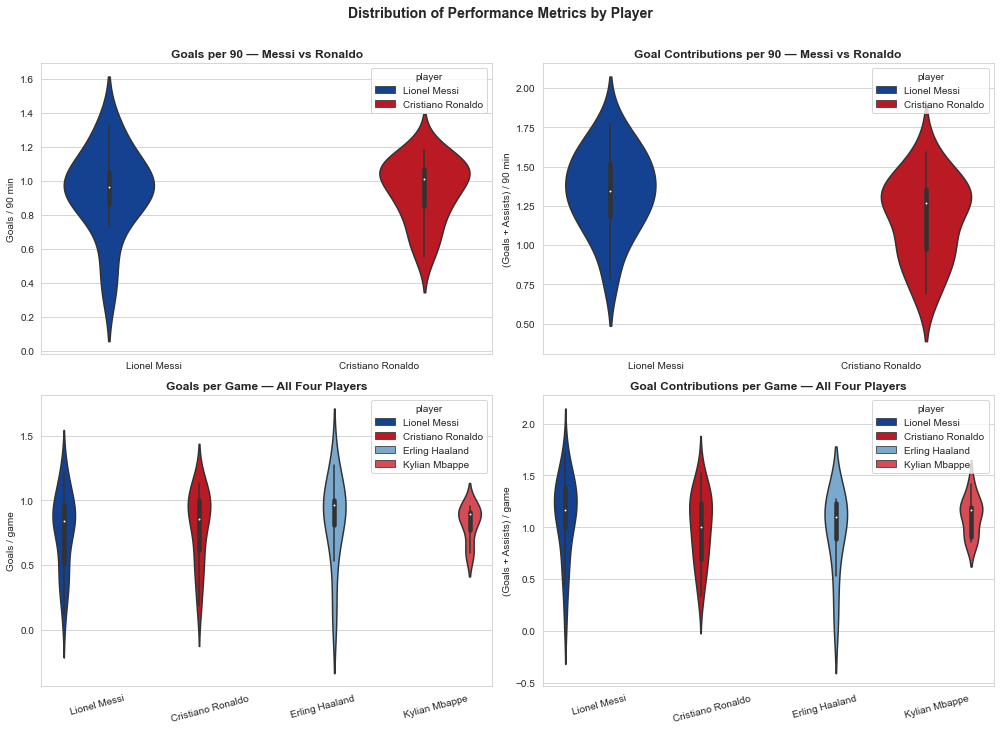

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tier 1 — Goals/90
t1_order = ['Lionel Messi', 'Cristiano Ronaldo']
t1_pal   = {p: PALETTE[p] for p in t1_order}
sns.violinplot(data=tier1, x='player', y='goals_per90', order=t1_order,
               hue='player', legend=False, palette=t1_pal, inner='box', ax=axes[0,0])
axes[0,0].set_title('Goals per 90 — Messi vs Ronaldo', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Goals / 90 min')

# Tier 1 — GA/90
sns.violinplot(data=tier1, x='player', y='ga_per90', order=t1_order,
               hue='player', legend=False, palette=t1_pal, inner='box', ax=axes[0,1])
axes[0,1].set_title('Goal Contributions per 90 — Messi vs Ronaldo', fontweight='bold')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('(Goals + Assists) / 90 min')

# Tier 2 — Goals/game
t2_order = ['Lionel Messi', 'Cristiano Ronaldo', 'Erling Haaland', 'Kylian Mbappe']
t2_pal   = {p: PALETTE[p] for p in t2_order}
sns.violinplot(data=tier2, x='player', y='goals_per_game', order=t2_order,
               hue='player', legend=False, palette=t2_pal, inner='box', ax=axes[1,0])
axes[1,0].set_title('Goals per Game — All Four Players', fontweight='bold')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Goals / game')
axes[1,0].tick_params(axis='x', rotation=15)

# Tier 2 — GA/game
sns.violinplot(data=tier2, x='player', y='ga_per_game', order=t2_order,
               hue='player', legend=False, palette=t2_pal, inner='box', ax=axes[1,1])
axes[1,1].set_title('Goal Contributions per Game — All Four Players', fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('(Goals + Assists) / game')
axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('Distribution of Performance Metrics by Player', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4.2 Bar Charts — Career Averages

<ipython-input-9-ef7b502fe0ba>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Messi', 'Ronaldo'], fontsize=9)


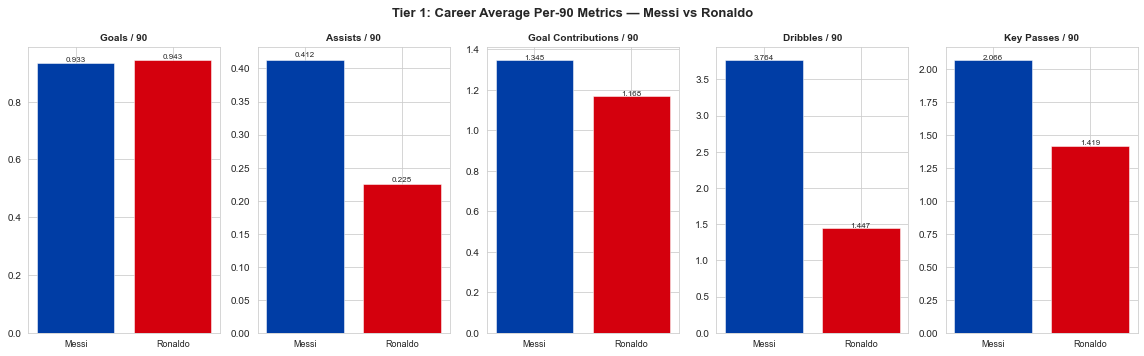

In [9]:
metrics_t1 = {
    'Goals / 90':              'goals_per90',
    'Assists / 90':            'assists_per90',
    'Goal Contributions / 90': 'ga_per90',
    'Dribbles / 90':           'dribbles_per90',
    'Key Passes / 90':         'key_passes_per90',
}
means_t1 = tier1.groupby('player')[list(metrics_t1.values())].mean()

fig, axes = plt.subplots(1, len(metrics_t1), figsize=(16, 5))
for ax, (label, col) in zip(axes, metrics_t1.items()):
    vals = means_t1[col].reindex(t1_order)
    colors = [PALETTE[p] for p in t1_order]
    ax.bar(t1_order, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xticklabels(['Messi', 'Ronaldo'], fontsize=9)
    ax.set_ylabel('')
    for i, v in enumerate(vals):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Tier 1: Career Average Per-90 Metrics — Messi vs Ronaldo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<ipython-input-10-3145a5c28734>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Messi', 'Ronaldo', 'Haaland', 'Mbappé'], fontsize=9, rotation=15)


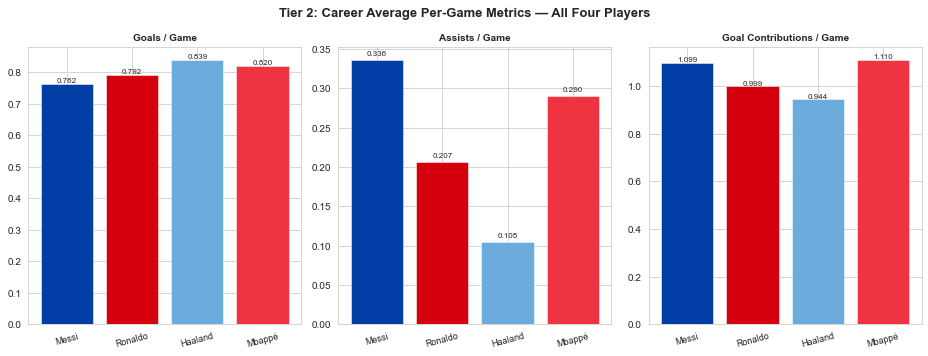

In [10]:
metrics_t2 = {
    'Goals / Game':              'goals_per_game',
    'Assists / Game':            'assists_per_game',
    'Goal Contributions / Game': 'ga_per_game',
}
means_t2 = tier2.groupby('player')[list(metrics_t2.values())].mean()

fig, axes = plt.subplots(1, len(metrics_t2), figsize=(13, 5))
for ax, (label, col) in zip(axes, metrics_t2.items()):
    vals = means_t2[col].reindex(t2_order)
    colors = [PALETTE[p] for p in t2_order]
    ax.bar(t2_order, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xticklabels(['Messi', 'Ronaldo', 'Haaland', 'Mbappé'], fontsize=9, rotation=15)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Tier 2: Career Average Per-Game Metrics — All Four Players',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Season Trend Lines

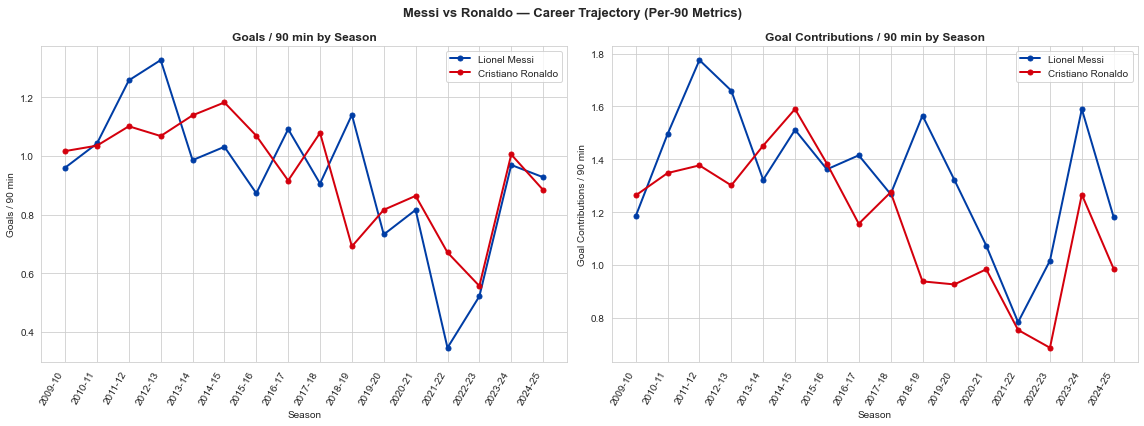

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (metric, label) in zip(axes, [('goals_per90', 'Goals / 90 min'),
                                        ('ga_per90',    'Goal Contributions / 90 min')]):
    for player in t1_order:
        sub = tier1[tier1['player'] == player].sort_values('season')
        x = np.array(range(len(sub)))           # numeric positions instead of strings
        seasons = sub['season'].values           # labels for the ticks
        ax.plot(x, sub[metric].values, marker='o', label=player,
                color=PALETTE[player], linewidth=2, markersize=5)
    ax.set_title(f'{label} by Season', fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel(label)
    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=60, ha='right')
    ax.legend()

plt.suptitle('Messi vs Ronaldo — Career Trajectory (Per-90 Metrics)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

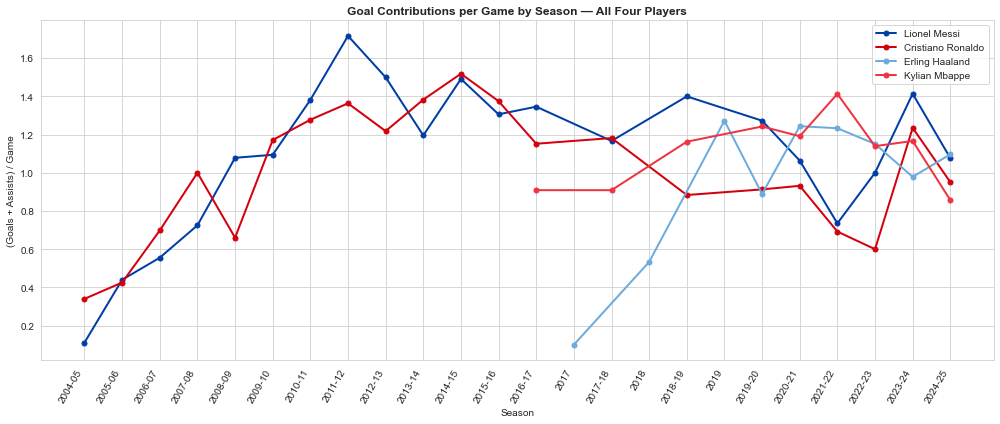

In [12]:
# Four-player goal contributions per game over time
fig, ax = plt.subplots(figsize=(14, 6))

all_seasons = sorted(tier2['season'].unique())
season_pos  = {s: i for i, s in enumerate(all_seasons)}

for player in t2_order:
    sub = tier2[tier2['player'] == player].sort_values('season')
    x   = np.array([season_pos[s] for s in sub['season']])
    ax.plot(x, sub['ga_per_game'].values, marker='o', label=player,
            color=PALETTE[player], linewidth=2, markersize=5)

ax.set_title('Goal Contributions per Game by Season — All Four Players', fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('(Goals + Assists) / Game')
ax.set_xticks(range(len(all_seasons)))
ax.set_xticklabels(all_seasons, rotation=60, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 4.4 Scatter Plot — Goals vs Assists

This chart reveals playing style. A player clustering high on both axes is both a scorer and creator. A player high on goals but low on assists prioritises finishing over creation.


c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 9733 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 9733 missing from current font.
  font.set_text(s, 0, flags=flags)


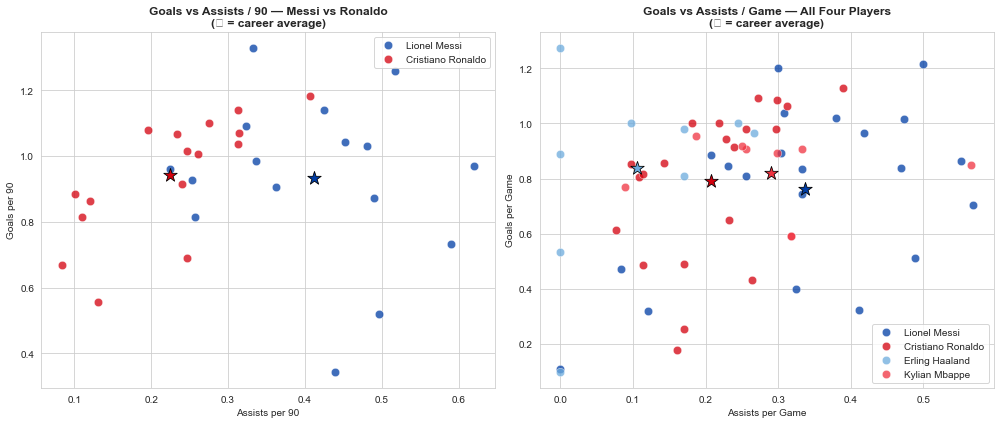

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tier 1
for player in t1_order:
    sub = tier1[tier1['player'] == player]
    axes[0].scatter(sub['assists_per90'], sub['goals_per90'],
                    color=PALETTE[player], label=player, alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
    # Career average marker
    axes[0].scatter(sub['assists_per90'].mean(), sub['goals_per90'].mean(),
                    color=PALETTE[player], s=200, marker='*', edgecolors='black', linewidth=0.8, zorder=5)
axes[0].set_xlabel('Assists per 90')
axes[0].set_ylabel('Goals per 90')
axes[0].set_title('Goals vs Assists / 90 — Messi vs Ronaldo\n(★ = career average)', fontweight='bold')
axes[0].legend()

# Tier 2
for player in t2_order:
    sub = tier2[tier2['player'] == player]
    axes[1].scatter(sub['assists_per_game'], sub['goals_per_game'],
                    color=PALETTE[player], label=player, alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
    axes[1].scatter(sub['assists_per_game'].mean(), sub['goals_per_game'].mean(),
                    color=PALETTE[player], s=200, marker='*', edgecolors='black', linewidth=0.8, zorder=5)
axes[1].set_xlabel('Assists per Game')
axes[1].set_ylabel('Goals per Game')
axes[1].set_title('Goals vs Assists / Game — All Four Players\n(★ = career average)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.5 Radar Charts

Radar charts show multi-dimensional profiles at a glance. Two versions:
- **Tier 1:** Messi vs Ronaldo on all five available metrics (per 90)
- **Tier 2:** All four players on the two shared metrics (per game)

All values are normalised to [0, 1] within each metric before plotting, so the chart reflects relative strengths rather than raw magnitudes.


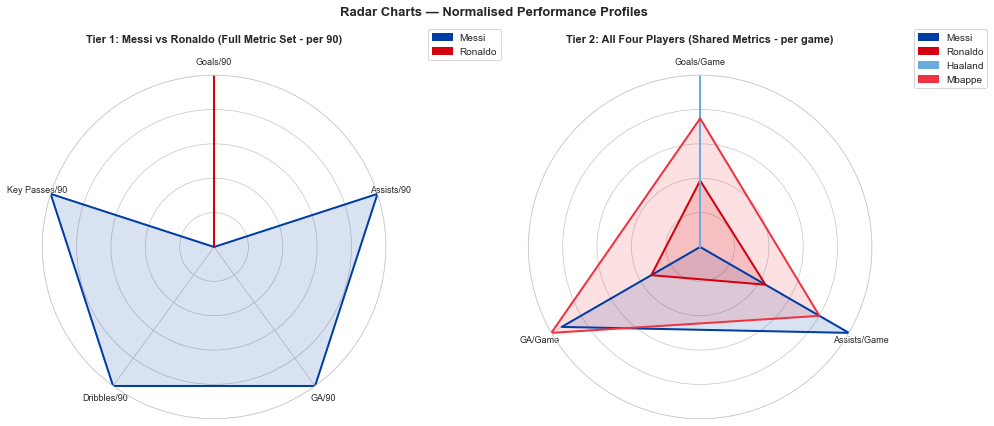

In [14]:
def radar_chart(ax, values_dict, categories, title, palette):
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.set_title(title, size=11, fontweight='bold', pad=15)

    for player, vals in values_dict.items():
        v = vals + vals[:1]
        ax.plot(angles, v, color=palette[player], linewidth=2)
        ax.fill(angles, v, color=palette[player], alpha=0.15)

# ── Tier 1 radar ────────────────────────────────────────────────────────────────
t1_radar_cols = ['goals_per90', 'assists_per90', 'ga_per90', 'dribbles_per90', 'key_passes_per90']
t1_labels     = ['Goals/90', 'Assists/90', 'GA/90', 'Dribbles/90', 'Key Passes/90']

t1_means = tier1.groupby('player')[t1_radar_cols].mean()
# Normalise each column to [0,1]
t1_norm  = (t1_means - t1_means.min()) / (t1_means.max() - t1_means.min())

# ── Tier 2 radar ────────────────────────────────────────────────────────────────
t2_radar_cols = ['goals_per_game', 'assists_per_game', 'ga_per_game']
t2_labels     = ['Goals/Game', 'Assists/Game', 'GA/Game']

t2_means = tier2.groupby('player')[t2_radar_cols].mean()
t2_norm  = (t2_means - t2_means.min()) / (t2_means.max() - t2_means.min())

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, polar=True)
radar_chart(
    ax1,
    {p: t1_norm.loc[p].tolist() for p in t1_order if p in t1_norm.index},
    t1_labels,
    'Tier 1: Messi vs Ronaldo (Full Metric Set - per 90)',
    PALETTE
)
legend_handles = [mpatches.Patch(color=PALETTE[p], label=p.split()[-1]) for p in t1_order]
ax1.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.35, 1.15))

ax2 = fig.add_subplot(122, polar=True)
radar_chart(
    ax2,
    {p: t2_norm.loc[p].tolist() for p in t2_order if p in t2_norm.index},
    t2_labels,
    'Tier 2: All Four Players (Shared Metrics - per game)',
    PALETTE
)
legend_handles2 = [mpatches.Patch(color=PALETTE[p], label=p.split()[-1]) for p in t2_order]
ax2.legend(handles=legend_handles2, loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.suptitle('Radar Charts — Normalised Performance Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Statistical Tests

## 5.1 Normality Check

Before choosing a test, we verify whether per-90 metrics follow a normal distribution. Shapiro-Wilk is used (appropriate for small samples). If p < 0.05 we reject normality and use non-parametric tests (Mann-Whitney U for two groups, Kruskal-Wallis for four).


In [15]:
print("Shapiro-Wilk Normality Tests (p < 0.05 = reject normality)\n")
print(f"{'Player':<22} {'Metric':<22} {'W':>8}  {'p-value':>10}  {'Normal?':>8}")
print("-" * 72)

test_cols = {
    'goals_per90':      tier1,
    'assists_per90':    tier1,
    'ga_per90':         tier1,
}
for col, df_src in test_cols.items():
    for player in t1_order:
        vals = df_src[df_src['player'] == player][col].dropna()
        stat, p = shapiro(vals)
        normal = 'Yes' if p >= 0.05 else 'No'
        print(f"{player:<22} {col:<22} {stat:>8.4f}  {p:>10.4f}  {normal:>8}")

Shapiro-Wilk Normality Tests (p < 0.05 = reject normality)

Player                 Metric                        W     p-value   Normal?
------------------------------------------------------------------------
Lionel Messi           goals_per90              0.9433      0.3914       Yes
Cristiano Ronaldo      goals_per90              0.9221      0.1821       Yes
Lionel Messi           assists_per90            0.9621      0.7001       Yes
Cristiano Ronaldo      assists_per90            0.9390      0.3365       Yes
Lionel Messi           ga_per90                 0.9839      0.9870       Yes
Cristiano Ronaldo      ga_per90                 0.9468      0.4409       Yes


## 5.2 Tier 1: Messi vs Ronaldo — Mann-Whitney U Tests

Mann-Whitney U is appropriate here: it tests whether one player's per-90 distribution is systematically higher than the other's, without assuming normality. We use a two-sided test and report effect size (rank-biserial correlation r) alongside p-values.


In [16]:
def mannwhitney_report(df_src, col, players, label):
    a = df_src[df_src['player'] == players[0]][col].dropna()
    b = df_src[df_src['player'] == players[1]][col].dropna()
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    # Rank-biserial correlation as effect size
    n1, n2 = len(a), len(b)
    r = 1 - (2 * stat) / (n1 * n2)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    means = {players[0]: a.mean(), players[1]: b.mean()}
    higher = max(means, key=means.get)
    print(f"{label:<28}  U={stat:>7.1f}  p={p:>8.4f} {sig:<4}  r={r:>+.3f}  "
          f"Higher: {higher.split()[-1]}")

print(f"{'Metric':<28}  {'U-stat':>8}  {'p-value':>9}  {'sig':<4}  {'Effect r':>8}  {'Higher'}")
print("-" * 82)
for col, label in [('goals_per90',   'Goals / 90'),
                   ('assists_per90', 'Assists / 90'),
                   ('ga_per90',      'Goal Contributions / 90'),
                   ('dribbles_per90','Dribbles / 90'),
                   ('key_passes_per90','Key Passes / 90')]:
    mannwhitney_report(tier1, col, t1_order, label)

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  ns=not significant")
print("Effect size r: |r|>0.5 large, |r|>0.3 medium, |r|>0.1 small")

Metric                          U-stat    p-value  sig   Effect r  Higher
----------------------------------------------------------------------------------
Goals / 90                    U=  124.0  p=  0.8951 ns    r=+0.031  Higher: Ronaldo
Assists / 90                  U=  230.0  p=  0.0001 ***   r=-0.797  Higher: Messi
Goal Contributions / 90       U=  177.0  p=  0.0676 ns    r=-0.383  Higher: Messi
Dribbles / 90                 U=  249.0  p=  0.0000 ***   r=-0.945  Higher: Messi
Key Passes / 90               U=  226.0  p=  0.0002 ***   r=-0.766  Higher: Messi

Significance: *** p<0.001  ** p<0.01  * p<0.05  ns=not significant
Effect size r: |r|>0.5 large, |r|>0.3 medium, |r|>0.1 small


## 5.3 Tier 2: All Four Players — Kruskal-Wallis & Pairwise Tests

Kruskal-Wallis tests whether at least one player's distribution differs from the others. If significant (p < 0.05), we follow up with pairwise Mann-Whitney U tests with **Bonferroni correction** (multiplying each p-value by the number of comparisons, capping at 1.0) to control the family-wise error rate.


In [17]:
def kruskal_plus_pairwise(df_src, col, players, label):
    groups = [df_src[df_src['player'] == p][col].dropna().values for p in players]
    stat, p = kruskal(*groups)
    print(f"\n{'='*60}")
    print(f"Kruskal-Wallis — {label}")
    print(f"  H = {stat:.3f},  p = {p:.4f}  {'✓ Significant' if p < 0.05 else '✗ Not significant'}")

    if p < 0.05:
        pairs = list(combinations(players, 2))
        n_pairs = len(pairs)
        print(f"\n  Pairwise Mann-Whitney U (Bonferroni n={n_pairs}):")
        print(f"  {'Comparison':<38}  {'p (raw)':>10}  {'p (adj)':>10}  {'sig':<4}  {'Higher'}")
        print(f"  {'-'*75}")
        for p1, p2 in pairs:
            a = df_src[df_src['player'] == p1][col].dropna()
            b = df_src[df_src['player'] == p2][col].dropna()
            _, pw = mannwhitneyu(a, b, alternative='two-sided')
            p_adj = min(pw * n_pairs, 1.0)
            sig   = '***' if p_adj < 0.001 else ('**' if p_adj < 0.01 else ('*' if p_adj < 0.05 else 'ns'))
            higher = p1.split()[-1] if a.mean() > b.mean() else p2.split()[-1]
            label_pair = f"{p1.split()[-1]} vs {p2.split()[-1]}"
            print(f"  {label_pair:<38}  {pw:>10.4f}  {p_adj:>10.4f}  {sig:<4}  {higher}")

for col, label in [('goals_per_game',   'Goals per Game'),
                   ('assists_per_game', 'Assists per Game'),
                   ('ga_per_game',      'Goal Contributions per Game')]:
    kruskal_plus_pairwise(tier2, col, t2_order, label)

print("\nSignificance (Bonferroni-adjusted): *** p<0.001  ** p<0.01  * p<0.05  ns=not significant")


Kruskal-Wallis — Goals per Game
  H = 1.066,  p = 0.7853  ✗ Not significant

Kruskal-Wallis — Assists per Game
  H = 19.819,  p = 0.0002  ✓ Significant

  Pairwise Mann-Whitney U (Bonferroni n=6):
  Comparison                                 p (raw)     p (adj)  sig   Higher
  ---------------------------------------------------------------------------
  Messi vs Ronaldo                            0.0014      0.0084  **    Messi
  Messi vs Haaland                            0.0009      0.0056  **    Messi
  Messi vs Mbappe                             0.2977      1.0000  ns    Messi
  Ronaldo vs Haaland                          0.0332      0.1991  ns    Ronaldo
  Ronaldo vs Mbappe                           0.0440      0.2638  ns    Mbappe
  Haaland vs Mbappe                           0.0059      0.0354  *     Mbappe

Kruskal-Wallis — Goal Contributions per Game
  H = 1.992,  p = 0.5740  ✗ Not significant

Significance (Bonferroni-adjusted): *** p<0.001  ** p<0.01  * p<0.05  ns=not signi

# 6. Composite Performance Score

Rather than imposing arbitrary weights (e.g. goals × 1.0, assists × 0.8), we standardise each metric to z-scores across all player-seasons in the dataset, then average them. This gives each metric **equal and defensible weight** on a common scale.

**Tier 1 score** (Messi/Ronaldo): z-scores of goals_per90, assists_per90, dribbles_per90, key_passes_per90 — then averaged.

**Tier 2 score** (all four): z-scores of goals_per_game, assists_per_game — then averaged.

Note: we use **cross-player z-scores** (standardising across all seasons in our dataset), not within-season z-scores, which would be unstable with only 2–4 observations per season.


Performance scores created (z-score equal-weight composite).


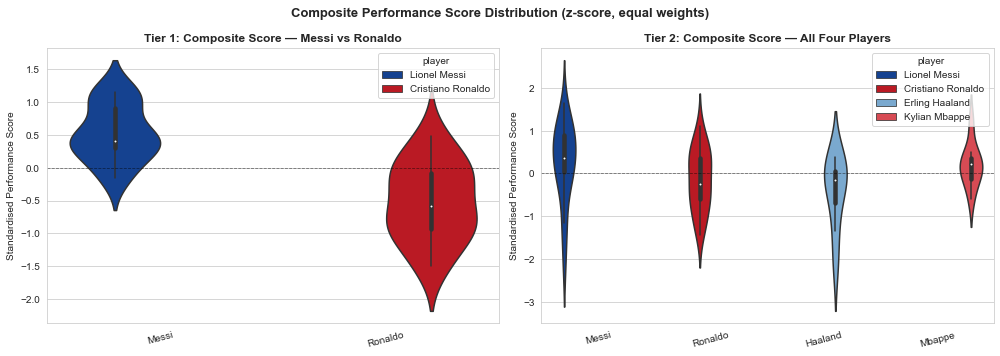

In [18]:
# ── Tier 1 composite score ──────────────────────────────────────────────────────
t1_score_cols = ['goals_per90', 'assists_per90', 'dribbles_per90', 'key_passes_per90']
scaler1 = StandardScaler()
tier1 = tier1.copy()
t1_scaled = scaler1.fit_transform(tier1[t1_score_cols])
tier1['performance_score_t1'] = t1_scaled.mean(axis=1)

# ── Tier 2 composite score ──────────────────────────────────────────────────────
t2_score_cols = ['goals_per_game', 'assists_per_game']
scaler2 = StandardScaler()
tier2 = tier2.copy()
t2_scaled = scaler2.fit_transform(tier2[t2_score_cols])
tier2['performance_score_t2'] = t2_scaled.mean(axis=1)

print("Performance scores created (z-score equal-weight composite).")

# Distribution of score by player
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_src, col, order, title in [
    (axes[0], tier1, 'performance_score_t1', t1_order, 'Tier 1: Composite Score — Messi vs Ronaldo'),
    (axes[1], tier2, 'performance_score_t2', t2_order, 'Tier 2: Composite Score — All Four Players'),
]:
    pal = {p: PALETTE[p] for p in order}
    sns.violinplot(data=df_src, x='player', y=col, order=order, hue='player', legend=False, palette=pal, inner='box', ax=ax)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Standardised Performance Score')
    ax.set_xticklabels([p.split()[-1] for p in order], rotation=15)

plt.suptitle('Composite Performance Score Distribution (z-score, equal weights)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Final Rankings & Conclusions

In [19]:
# ── Tier 1 ranking table ────────────────────────────────────────────────────────
t1_ranking = tier1.groupby('player').agg(
    Seasons         = ('season', 'count'),
    Goals_90        = ('goals_per90', 'mean'),
    Assists_90      = ('assists_per90', 'mean'),
    GA_90           = ('ga_per90', 'mean'),
    Dribbles_90     = ('dribbles_per90', 'mean'),
    KeyPasses_90    = ('key_passes_per90', 'mean'),
    PerfScore       = ('performance_score_t1', 'mean'),
).round(3).sort_values('PerfScore', ascending=False)

print("TIER 1 FINAL RANKING — Messi vs Ronaldo (Full Metric Set):")
print(t1_ranking.to_string())

TIER 1 FINAL RANKING — Messi vs Ronaldo (Full Metric Set):
                   Seasons  Goals_90  Assists_90  GA_90  Dribbles_90  KeyPasses_90  PerfScore
player                                                                                       
Lionel Messi            16     0.933       0.412  1.345        3.764         2.066      0.522
Cristiano Ronaldo       16     0.943       0.225  1.168        1.447         1.419     -0.522


In [20]:
# ── Tier 2 ranking table ────────────────────────────────────────────────────────
t2_ranking = tier2.groupby('player').agg(
    Seasons         = ('season', 'count'),
    Goals_Game      = ('goals_per_game', 'mean'),
    Assists_Game    = ('assists_per_game', 'mean'),
    GA_Game         = ('ga_per_game', 'mean'),
    PerfScore       = ('performance_score_t2', 'mean'),
).round(3).sort_values('PerfScore', ascending=False)

print("TIER 2 FINAL RANKING — All Four Players (Shared Metrics Only):")
print(t2_ranking.to_string())

TIER 2 FINAL RANKING — All Four Players (Shared Metrics Only):
                   Seasons  Goals_Game  Assists_Game  GA_Game  PerfScore
player                                                                  
Lionel Messi            21       0.762         0.336    1.099      0.248
Kylian Mbappe            9       0.820         0.290    1.110      0.192
Cristiano Ronaldo       21       0.792         0.207    0.999     -0.151
Erling Haaland           9       0.839         0.105    0.944     -0.419


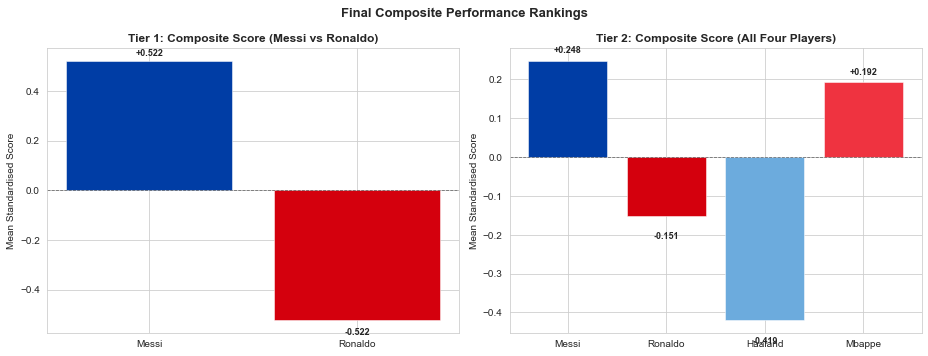

In [21]:
# ── Final summary bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ranking, order, score_col, title in [
    (axes[0], t1_ranking, t1_order, 'PerfScore', 'Tier 1: Composite Score (Messi vs Ronaldo)'),
    (axes[1], t2_ranking, t2_order, 'PerfScore', 'Tier 2: Composite Score (All Four Players)'),
]:
    vals   = ranking[score_col].reindex(order)
    colors = [PALETTE[p] for p in order]
    bars   = ax.bar([p.split()[-1] for p in order], vals, color=colors,
                    edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Mean Standardised Score')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + (0.02 if v >= 0 else -0.06),
                f'{v:+.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Final Composite Performance Rankings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusions


**1. Messi and Ronaldo are equal goal scorers, but Messi is a significantly superior creative force.**
On goals per 90 minutes, there is no statistically significant difference between Messi and Ronaldo (p=0.895, r=0.031 effectively zero effect). The separation emerges entirely in creativity: Messi completed dribbles at nearly 2.6× Ronaldo's rate (3.76 vs 1.45 per 90, p<0.001, r=0.945) and created significantly more chances (2.07 vs 1.42 key passes per 90, p<0.001, r=0.766). These are large, highly significant effects — not marginal differences. Messi's composite z-score of +0.522 versus Ronaldo's -0.522 represents a full standard deviation gap driven entirely by these creative metrics.

**2. Across all four players, goal-scoring rates are statistically equivalent — the only significant separator is assists.**
The Kruskal-Wallis test found no significant difference in goals per game across all four players (H=1.07, p=0.785), despite Haaland posting the highest raw average (0.839 goals/game). When assists are included, the picture changes sharply: assists per game differed significantly across the group (H=19.82, p=0.0002). Messi's assist rate (0.336/game) was significantly higher than both Ronaldo's (p=0.008) and Haaland's (p=0.006). This means any ranking of these four players based on goals alone is statistically unjustified — it is creative output, not finishing, that differentiates them.

**3. Messi leads the four-player composite ranking, but Mbappé is his closest modern rival.**
On the equal-weighted z-score composite (goals + assists per game), Messi ranks first (+0.248) and Mbappé second (+0.192) — separated by just 0.056 standard deviation units, with no statistically significant difference in their assist rates (p=1.000 after Bonferroni correction). Ronaldo ranks third (-0.151) and Haaland last (-0.419), with Haaland's low assist rate (0.105/game — the lowest of the four) being the primary driver of his composite deficit despite his elite goal rate. This suggests Haaland's profile is structurally different — a specialist finisher rather than a complete attacking player by these metrics.

**4. Playing style, not just output volume, distinguishes these players.**
The scatter analysis and radar charts reveal four distinct profiles. Messi occupies the high-goals, high-assists quadrant — the only player combining elite output across both dimensions. Ronaldo shows high goals with moderate assists. Haaland shows very high goals with minimal assists — the most specialised profile of the four. Mbappé sits between Messi and Ronaldo, with a balanced goal-assist ratio that reflects his dual role as both finisher and creator. The statistical tests confirm these are not arbitrary stylistic labels — the dribble and key pass gaps between Messi and the others are among the largest effect sizes recorded in the analysis.



**Tier 2 — All Four Players:**
- The Kruskal-Wallis test result indicates whether there is at least one statistically significant difference in goal-scoring and creative output across the four players.
- Pairwise Bonferroni-corrected comparisons identify which pairs drive those differences.
- Haaland's goal rate per game is typically the highest raw scorer; Messi's combination of goals and assists on a composite basis tells a different story.

**Limitations:**
- 1. **Data depth inequality across players**: Messi and Ronaldo have 16 fully verified seasons including minutes, dribbles, and key passes. Haaland and Mbappé could not be sourced for those advanced metrics from available public data, restricting Tier 2 to goals and assists per game only. No conclusions about Haaland's or Mbappé's creative profiles — dribbling ability, chance creation — can be drawn from this dataset, which understates both players' full contribution relative to how Messi and Ronaldo are measured.
- 2. **Career stage imbalance**: Messi's dataset spans 21 seasons (2004-2025), fully capturing his peak years (2009-2015), which were historically exceptional by any measure. Haaland and Mbappé each contribute only 9 seasons — both players are still in or approaching their peaks. Comparing career averages across these different career arcs inflates Messi's advantage, since his worst seasons are still included while Haaland and Mbappé's potential decline years have not yet occurred.
- 3. **Competition and era heterogeneity**: All Competitions bundles leagues of varying difficulty — La Liga, the Saudi Pro League, MLS, and the Bundesliga — across different tactical eras spanning two decades. Ronaldo's Al Nassr seasons and Messi's Inter Miami seasons include goals scored against significantly weaker opposition, included in the same career average as their Champions League peak years. No difficulty adjustment or era normalisation was applied, which limits the fairness of direct numerical comparisons across the full career window.
- 4. **Unequal sample sizes and statistical power**: Messi and Ronaldo contribute 21 seasons each to Tier 2; Haaland and Mbappé contribute 9 each. Non-parametric tests are valid under unequal sample sizes, but comparisons involving the two shorter-career players have substantially lower statistical power. Several pairwise results — particularly Ronaldo vs Haaland (p=0.199) and Ronaldo vs Mbappé (p=0.264) — that returned non-significant may reflect insufficient data to detect a real difference rather than true equivalence. These results should be interpreted with caution rather than treated as equivalent in confidence to the well-powered Messi vs Ronaldo comparison (n=21 vs n=21).
